# Instructor Effectiveness Modeling

## EdTech Context

### Objective
The objective of this project is to evaluate instructor effectiveness using learner outcomes, engagement, retention, and feedback metrics.

The analysis aggregates batch-level data to the instructor level, creates a weighted effectiveness score, classifies instructors into Low, Medium, and High effectiveness tiers, and builds a machine learning model to identify patterns associated with these tiers.

### Approach
1. Load and inspect the dataset
2. Perform data quality checks
3. Aggregate batch-level metrics to instructor level
4. Normalize relevant performance metrics
5. Create a weighted effectiveness score
6. Classify instructors into effectiveness tiers
7. Train a Random Forest classifier
8. Evaluate model performance
9. Analyze feature importance
10. Discuss business, ethical, and real-world limitations

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("Setup successful!")

Setup successful!


## 1. Dataset Overview

The dataset contains instructor-level performance information derived from multiple course batches.

The key variables represent:

- Learner outcomes: completion rate, score improvement, and quiz score
- Retention: dropout rate
- Engagement: watch time, assignment submission, and forum activity
- Feedback: feedback score and response rate
- Instructor identifier and batch information

In [33]:
import pandas as pd

df = pd.read_excel(r"C:\Users\LENOVO\Downloads\instructor_effectiveness_dataset_2000_rows - Google Sheets.xlsx")

df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_impro,avg_quiz_score,dropout_rate,avg_watch_time,assignment_sub,forum_activity_ra,avg_feedback_sc,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [34]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (2000, 12)

Columns:
['batch_id', 'instructor_id', 'course_id', 'completion_rate', 'avg_score_impro', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_sub', 'forum_activity_ra', 'avg_feedback_sc', 'feedback_response_rate']


In [35]:
df.isnull().sum()

batch_id                  0
instructor_id             0
course_id                 0
completion_rate           0
avg_score_impro           0
avg_quiz_score            0
dropout_rate              0
avg_watch_time            0
assignment_sub            0
forum_activity_ra         0
avg_feedback_sc           0
feedback_response_rate    0
dtype: int64

## 2. Data Quality Check

The dataset was checked for missing values, duplicate records, and basic statistical properties.

No missing values or duplicate rows were found, so no imputation or duplicate removal was required.

In [36]:
print("Duplicate rows:", df.duplicated().sum())
print("\nBasic Statistics:")
display(df.describe())

Duplicate rows: 0

Basic Statistics:


,completion_rate,avg_score_impro,avg_quiz_score,dropout_rate,avg_watch_time,assignment_sub,forum_activity_ra,avg_feedback_sc,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [37]:
df.dtypes

batch_id                   object
instructor_id              object
course_id                  object
completion_rate           float64
avg_score_impro           float64
avg_quiz_score            float64
dropout_rate              float64
avg_watch_time            float64
assignment_sub            float64
forum_activity_ra         float64
avg_feedback_sc           float64
feedback_response_rate    float64
dtype: object

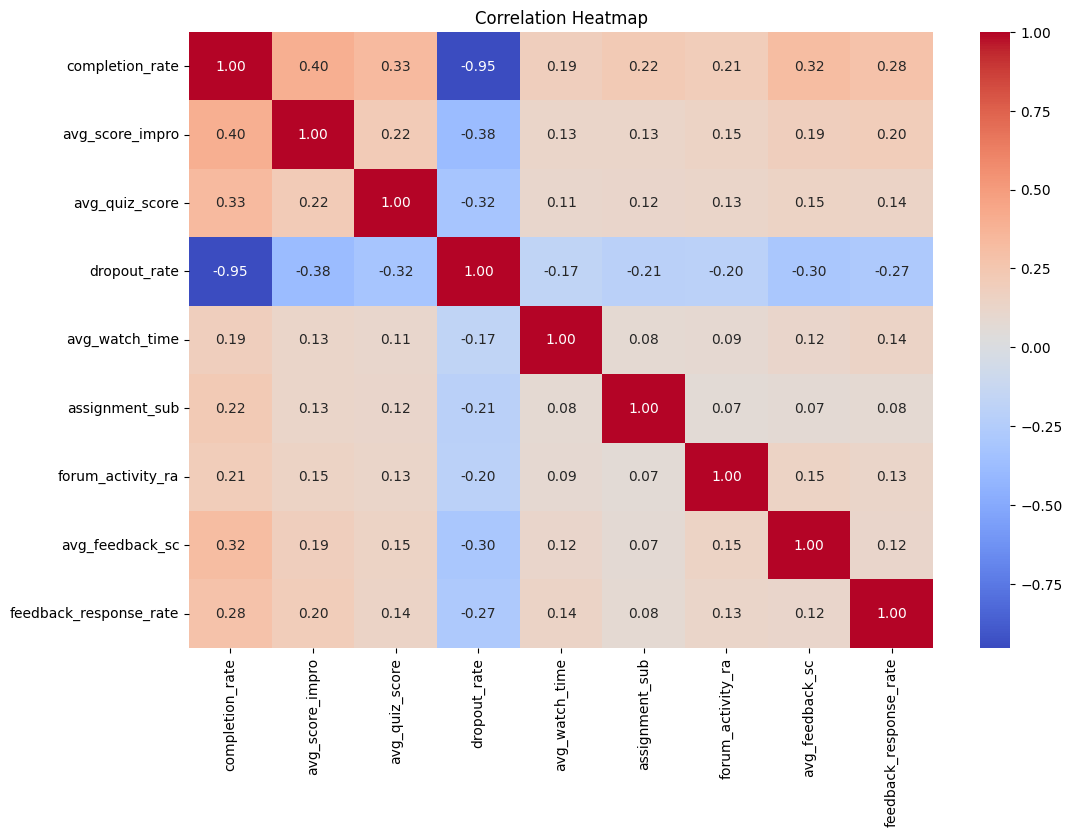

In [38]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [39]:
df.columns.tolist()

['batch_id',
 'instructor_id',
 'course_id',
 'completion_rate',
 'avg_score_impro',
 'avg_quiz_score',
 'dropout_rate',
 'avg_watch_time',
 'assignment_sub',
 'forum_activity_ra',
 'avg_feedback_sc',
 'feedback_response_rate']

In [40]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()

numeric_cols

['completion_rate',
 'avg_score_impro',
 'avg_quiz_score',
 'dropout_rate',
 'avg_watch_time',
 'assignment_sub',
 'forum_activity_ra',
 'avg_feedback_sc',
 'feedback_response_rate']

In [41]:
instructor_df = df.groupby('instructor_id')[numeric_cols].mean().reset_index()

instructor_df['batch_count'] = df.groupby('instructor_id').size().values

instructor_df.head()

,instructor_id,completion_rate,avg_score_impro,avg_quiz_score,dropout_rate,avg_watch_time,assignment_sub,forum_activity_ra,avg_feedback_sc,feedback_response_rate,batch_count
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,25
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,20
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,18
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,17
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,19


## 3. Instructor-Level Aggregation

Since the original dataset contains batch-level observations, the data was aggregated by instructor_id.

For each instructor, the mean value of the available performance, engagement, retention, and feedback metrics was calculated.

This produces one consolidated record per instructor, which allows instructor-level effectiveness to be analyzed.

### Aggregation Limitation

The aggregation uses a simple mean across batches. Therefore, each batch contributes equally, regardless of its learner count.

A weighted aggregation based on the number of learners per batch would be preferable if learner-count information were available.

In [42]:
print("Instructor-level shape:", instructor_df.shape)
print("\nColumns:")
print(instructor_df.columns.tolist())

Instructor-level shape: (120, 11)

Columns:
['instructor_id', 'completion_rate', 'avg_score_impro', 'avg_quiz_score', 'dropout_rate', 'avg_watch_time', 'assignment_sub', 'forum_activity_ra', 'avg_feedback_sc', 'feedback_response_rate', 'batch_count']


## 4. Feature Normalization

Min-Max scaling was applied to the numeric performance metrics so that the variables are placed on a comparable scale before constructing the effectiveness score.

In [57]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scale_cols = [
    'completion_rate',
    'avg_score_impro',
    'avg_quiz_score',
    'dropout_rate',
    'avg_watch_time',
    'assignment_sub',
    'forum_activity_ra',
    'avg_feedback_sc',
    'feedback_response_rate'
]

instructor_df[scale_cols] = scaler.fit_transform(
    instructor_df[scale_cols]
)

### Dropout Rate Transformation

A lower dropout rate represents better instructor effectiveness. Therefore, the dropout metric was transformed so that a higher value consistently represents better performance across the effectiveness score components.

In [44]:
instructor_df['dropout_rate'] = 1 - instructor_df['dropout_rate']

In [45]:
instructor_df.columns.tolist()

['instructor_id',
 'completion_rate',
 'avg_score_impro',
 'avg_quiz_score',
 'dropout_rate',
 'avg_watch_time',
 'assignment_sub',
 'forum_activity_ra',
 'avg_feedback_sc',
 'feedback_response_rate',
 'batch_count']

In [46]:
instructor_df.columns.tolist()

['instructor_id',
 'completion_rate',
 'avg_score_impro',
 'avg_quiz_score',
 'dropout_rate',
 'avg_watch_time',
 'assignment_sub',
 'forum_activity_ra',
 'avg_feedback_sc',
 'feedback_response_rate',
 'batch_count']

In [47]:
instructor_df['effectiveness_score'] = (
    0.15 * instructor_df['completion_rate'] +
    0.05 * instructor_df['dropout_rate'] +
    0.20 * instructor_df['avg_score_impro'] +
    0.20 * instructor_df['avg_quiz_score'] +
    0.07 * instructor_df['avg_watch_time'] +
    0.08 * instructor_df['assignment_sub'] +
    0.05 * instructor_df['forum_activity_ra'] +
    0.15 * instructor_df['avg_feedback_sc'] +
    0.05 * instructor_df['feedback_response_rate']
)

instructor_df[['instructor_id', 'effectiveness_score']].head()

,instructor_id,effectiveness_score
0,I_001,0.475107
1,I_002,0.679594
2,I_003,0.705835
3,I_004,0.385353
4,I_005,0.789958


## 5. Effectiveness Score

A weighted effectiveness score was created using learner outcomes, engagement, retention, and feedback indicators.

Higher weights were assigned to learner outcomes and feedback-related measures because they provide stronger direct signals of learning results and instructor interaction.

The weights represent a baseline analytical framework and are not intended to establish causal relationships.

### Interpretation

The resulting score provides a consistent way to rank instructors across the selected dimensions.

However, the score should be treated as an analytical framework rather than an objective or universally valid definition of instructor quality.

In [48]:
instructor_df['effectiveness_tier'] = pd.qcut(
    instructor_df['effectiveness_score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

instructor_df['effectiveness_tier'].value_counts()

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

## 6. Effectiveness Tiers

Instructors were divided into three effectiveness tiers: Low, Medium, and High.

Quantile-based classification was used to create approximately balanced groups, with each tier containing a similar number of instructors.

These tiers are relative to the instructors present in this dataset and should not be interpreted as absolute performance standards.

In [49]:
feature_cols = [
    'completion_rate',
    'avg_score_impro',
    'avg_quiz_score',
    'dropout_rate',
    'avg_watch_time',
    'assignment_sub',
    'forum_activity_ra',
    'avg_feedback_sc',
    'feedback_response_rate',
    'batch_count'
]

X = instructor_df[feature_cols]
y = instructor_df['effectiveness_tier']

## 7. Machine Learning Model

The effectiveness tier was used as the target variable.

The effectiveness score itself was excluded from the input features because it directly defines the target tiers and including it would create target leakage.

A Random Forest classifier was selected because it can capture nonlinear relationships between the different instructor-level metrics.

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [51]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model training completed!")

Model training completed!


## 8. Model Evaluation

The model was evaluated using accuracy and classification metrics including precision, recall, and F1-score.

Because the target contains three effectiveness classes, macro F1-score is also considered to evaluate performance across all classes.

In [52]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.90      0.95        10
         Low       0.90      0.90      0.90        10
      Medium       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.91      0.90      0.90        30
weighted avg       0.91      0.90      0.90        30



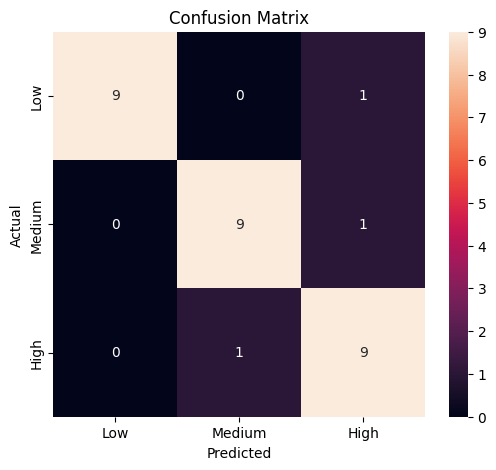

In [53]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows how effectively the model distinguishes between Low, Medium, and High effectiveness instructors.

Most predictions fall along the diagonal, indicating that the model correctly identifies the corresponding effectiveness tier for most test observations.

In [54]:
importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

display(importance)

,Feature,Importance
0,completion_rate,0.234104
8,feedback_response_rate,0.190552
3,dropout_rate,0.178506
1,avg_score_impro,0.132039
2,avg_quiz_score,0.095717
7,avg_feedback_sc,0.066733
6,forum_activity_ra,0.044154
4,avg_watch_time,0.027759
5,assignment_sub,0.018421
9,batch_count,0.012014


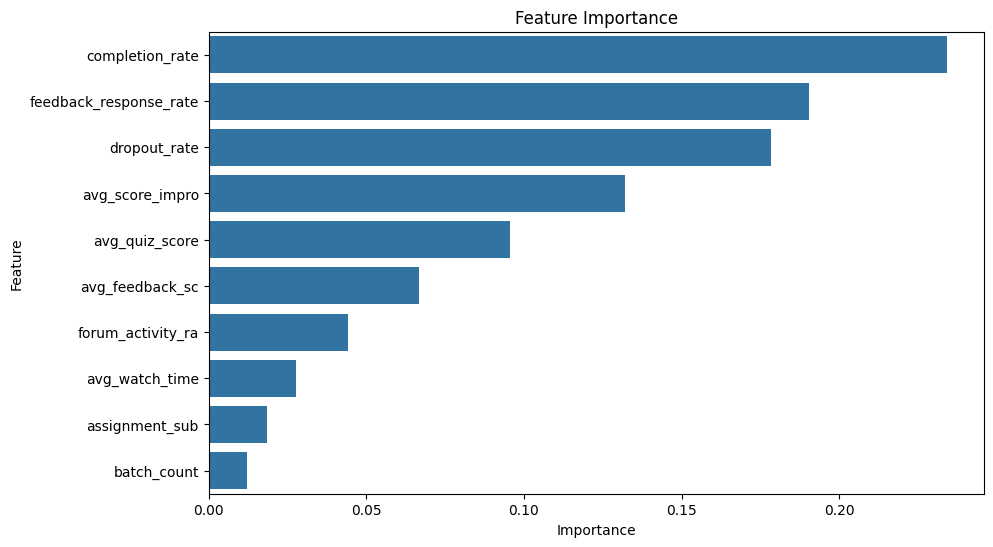

In [55]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 9. Feature Importance Analysis

The feature importance results indicate that completion rate, feedback response rate, dropout rate, and average score improvement were among the most influential variables for distinguishing instructor effectiveness tiers.

Completion rate and score improvement provide direct signals of learner progress and course completion. Feedback response rate may indicate the level of instructor interaction with learners, while the transformed dropout metric represents learner retention.

These results indicate predictive importance, not causation. A high feature importance does not prove that the instructor directly caused the observed learner outcome.

# 10. Business & Ethical Analysis

## 1. Which features most influenced instructor effectiveness, and why?

The most influential features were completion rate, feedback response rate, dropout rate, and average score improvement.

These variables are useful because they capture learner completion, retention, learning progress, and instructor interaction. However, feature importance represents predictive usefulness rather than causal influence.

## 2. Which variables could be misleading or confounded?

Several variables may be affected by factors other than instructor performance.

- Completion rate can depend on learner motivation and personal circumstances.
- Dropout rate can be influenced by financial, academic, or personal reasons.
- Quiz scores can depend on assessment difficulty and learner background.
- Watch time does not necessarily indicate effective learning.
- Forum activity can vary based on learner participation habits.
- Feedback scores may be affected by response bias.
- Assignment submission can be influenced by workload and course difficulty.
- Course difficulty and learner characteristics may confound instructor-level comparisons.

## 3. How could this model fail in real-world usage?

The model may not generalize well to new instructors, courses, or learner populations.

Changes in course difficulty, assessment methods, learner characteristics, or feedback behavior could change the relationship between the features and effectiveness tiers.

The model could also incorrectly attribute learner outcomes to instructors when those outcomes are influenced by external factors.

## 4. What additional data would you want?

Useful additional data would include:

- Number of learners per batch
- Learner pre-test and post-test scores
- Course difficulty
- Instructor experience
- Attendance
- Assignment quality
- Learner-level feedback
- Course category
- Historical instructor performance

## 5. Should this model be used for instructor performance evaluation? Why or why not?

The model should not be used as the sole basis for evaluating instructor performance.

It should be used as a decision-support tool alongside human review, course context, learner feedback, and historical performance.

Using the model alone for decisions such as promotion, compensation, or termination could be unfair because many factors affecting learner outcomes are outside the instructor's control.

# 11. Limitations

### 1. Target construction

The effectiveness tiers were created from the same underlying metrics that were later provided to the machine learning model. Therefore, the model primarily learns to reproduce the defined scoring framework rather than predict an independently observed ground-truth measure of instructor effectiveness.

### 2. Equal batch weighting

The instructor-level aggregation uses mean values, so batches contribute equally regardless of learner count.

### 3. Course and learner confounding

Instructor performance metrics can be affected by course difficulty, learner preparedness, learner motivation, and other contextual factors.

### 4. Limited dataset context

The available dataset does not include several potentially important variables such as learner counts, course difficulty, instructor experience, and learner baseline performance.

### 5. Feature correlation

Some engagement, outcome, and feedback variables may be correlated with each other, which can affect feature-importance interpretation.

# 12. Conclusion

This project developed an instructor effectiveness framework using learner outcomes, engagement, retention, and feedback metrics.

Batch-level observations were aggregated to the instructor level, normalized, and combined into a weighted effectiveness score. Instructors were then classified into Low, Medium, and High effectiveness tiers.

A Random Forest classifier was used to identify patterns associated with these tiers, and feature importance was used to interpret the model.

The results provide useful analytical insights, but the model should be treated as a decision-support system rather than an objective measure of instructor quality.

Most importantly, the target tiers were derived from the same underlying features used by the model. Therefore, the current model should not be interpreted as independently validating instructor effectiveness. A stronger future approach would use an independently defined outcome or longitudinal instructor-performance measure as the target.